# Mean- Median Imputation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('titanic_toy.csv')

df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [4]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [5]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [6]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

In [7]:
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)

In [8]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [9]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [10]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [11]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [12]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
22,15.0,8.0292,0,15.0,15.000000,8.0292,8.0292
181,NaN,15.0500,0,28.0,29.498846,15.0500,15.0500
14,14.0,7.8542,0,14.0,14.000000,7.8542,7.8542
95,NaN,8.0500,0,28.0,29.498846,8.0500,8.0500
811,39.0,24.1500,0,39.0,39.000000,24.1500,24.1500


In [13]:
print('Original Age Variable Variance',X_train['Age'].var())
print('Age Variance after mean imputation', X_train['Age_mean'].var())
print('Age Varinace after median imputation', X_train['Age_median'].var())
print()
print('Original Fare Variable Variance',X_train['Fare'].var())
print('Fare Variance after mean imputation', X_train['Fare_mean'].var())
print('Fare Varinace after median imputation', X_train['Fare_median'].var())

Original Age Variable Variance 210.2517072477438
Age Variance after mean imputation 168.8519336687225
Age Varinace after median imputation 169.20731007048096

Original Fare Variable Variance 2761.031434948639
Fare Variance after mean imputation 2621.2323749512393
Fare Varinace after median imputation 2637.01248167777


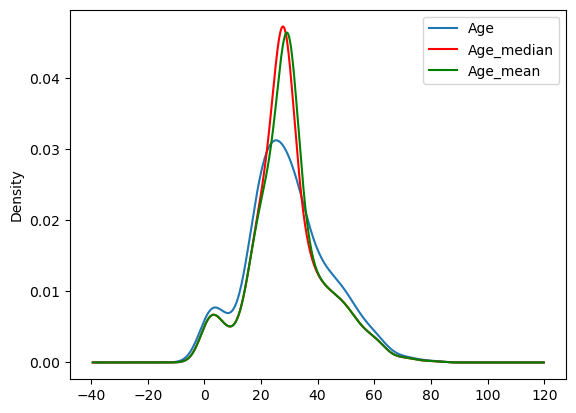

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind = 'kde', ax = ax)

X_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'red')

X_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc= 'best')

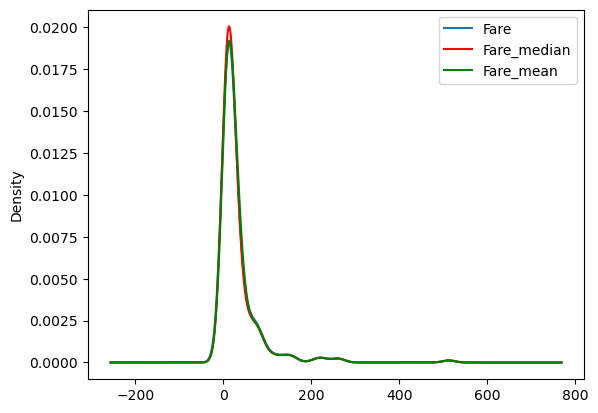

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind = 'kde', ax = ax)

X_train['Fare_median'].plot(kind = 'kde', ax = ax, color = 'red')

X_train['Fare_mean'].plot(kind = 'kde', ax = ax, color = 'green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc= 'best')

In [17]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


<Axes: >

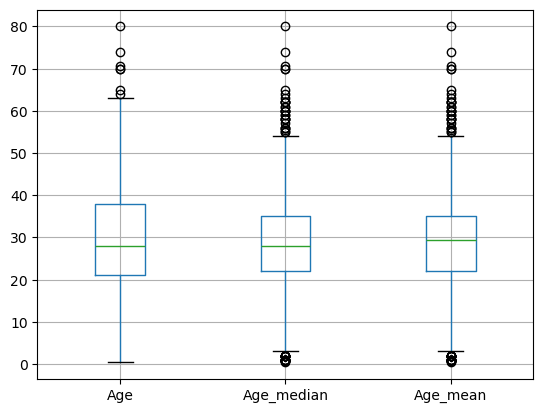

In [18]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

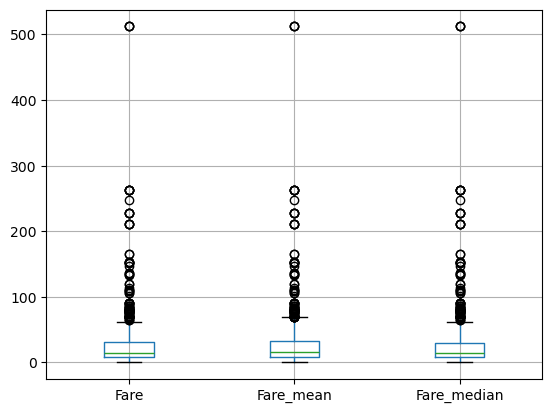

In [19]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

# Using Sklearn

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [21]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')

In [22]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
], remainder = 'passthrough')

In [23]:
trf.fit(X_train)

C:\Users\Om\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [24]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [25]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [26]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [32]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])